In [1]:
# %%
import argparse
import time
import numpy as np
import matplotlib.pyplot as plt
import os

from arguments import add_arguments
from ilqr.multiLQR import *
from visualize import draw_car
from collections import deque

def dist(a, b):
    return ((a[0] - b[0])**2 + (a[1] - b[1])**2)**0.5
# %%
def timer_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        epochs = kwargs.get('epochs', 'unknown number of')
        print(f"Running {func.__name__} for {epochs} epochs took {end_time - start_time} seconds.")
        print(f"The average time for each epoch is {(end_time - start_time)/epochs} seconds.")
        return result
    return wrapper

class SimParams:    
    agent1_start_state = np.array([15, -5, 0, 0])
    agent2_start_state = np.array([50, -30, 0, np.pi/2])
    agent3_start_state = np.array([40, 30, 0, -np.pi/2])
    agent4_start_state = np.array([50, -30, 0, np.pi/2])
    # agent4_start_state = np.array([90, 5, 0, np.pi])



# %%
def create_global_plan_1():
    x1 = np.arange(15, 50)  
    y1 = np.full_like(x1, -5) 

    y2 = np.arange(-5, 30)  
    x2 = np.full_like(y2, 50)  

    x_coords = np.concatenate((x1, x2))
    y_coords = np.concatenate((y1, y2))

    points = np.array([x_coords, y_coords]).T
    # print(points.shape)
    return points

def create_global_plan_2():
    y1 = np.arange(-30, 5)
    x1 = np.full_like(y1, 50) 

    x2 = np.arange(50, 10, -1)
    y2 = np.full_like(x2, 5)

    x_coords = np.concatenate((x1, x2))
    y_coords = np.concatenate((y1, y2))

    points = np.array([x_coords, y_coords]).T
    return points

def create_global_plan_3():
    y1 = np.arange(30, -5, -1)
    x1 = np.full_like(y1, 40) 

    x2 = np.arange(40, 70)
    y2 = np.full_like(x2, -5)

    x_coords = np.concatenate((x1, x2))
    y_coords = np.concatenate((y1, y2))

    points = np.array([x_coords, y_coords]).T
    return points

def create_global_plan_4():
    y1 = np.arange(-30, 40)
    x1 = np.full_like(y1, 50)
    x_coords = x1
    y_coords = y1
    # x1 = np.arange(90, 20, -1)
    # y1 = np.full_like(x1, 5)
    # y2 = np.arange(5, -20, -1)
    # x2 = np.full_like(y2, 40)
    # x_coords = np.concatenate((x1, x2))
    # y_coords = np.concatenate((y1, y2))

    points = np.array([x_coords, y_coords]).T
    return points

# %%
class multiAgentSimulator:
    def __init__(self, args, SimParams):
        self.args = args

        self.simparams = SimParams
        self.navigation_agent1 = None
        self.navigation_agent2 = None
        self.navigation_agent3 = None
        self.navigation_agent4 = None
        self.nominal_control = np.zeros((2, self.args.horizon))
        self.nominal_control[0,:] = np.linspace(self.args.acc_control_limits[1], 0, self.args.horizon)
        
        self.count = 0
        self.count_short = 0
        self.current_agent1_state_long = self.simparams.agent1_start_state
        self.current_agent2_state_long = self.simparams.agent2_start_state
        self.current_agent3_state_long = self.simparams.agent3_start_state
        # self.current_agent4_state_long = self.simparams.agent4_start_state
        
        self.last_agent1_states = np.expand_dims(self.simulate_states(
            self.current_agent1_state_long, self.nominal_control), axis=0)
        self.last_agent2_states = np.expand_dims(self.simulate_states(
            self.current_agent2_state_long, self.nominal_control), axis=0)
        self.last_agent3_states = np.expand_dims(self.simulate_states(
            self.current_agent3_state_long, self.nominal_control), axis=0)
        # self.last_agent4_states = np.expand_dims(self.simulate_states(
        #     self.current_agent4_state_long, self.nominal_control), axis=0)
        
        self.agent1_states_long = [self.current_agent1_state_long]
        self.agent2_states_long = [self.current_agent2_state_long]
        self.agent3_states_long = [self.current_agent3_state_long]
        # self.agent4_states_long = [self.current_agent4_state_long]
        self.agent1_states_short = [self.current_agent1_state_long]
        self.agent2_states_short = [self.current_agent2_state_long]
        self.agent3_states_short = [self.current_agent3_state_long]
        # self.agent4_states_short = [self.current_agent4_state_long]

        self.tmp_agent1_states_long = deque(maxlen=20)
        self.tmp_agent1_controls_long = deque(maxlen=20)
        self.tmp_agent2_states_long = deque(maxlen=20)
        self.tmp_agent2_controls_long = deque(maxlen=20)
        self.tmp_agent3_states_long = deque(maxlen=20)
        self.tmp_agent3_controls_long = deque(maxlen=20)
        # self.tmp_agent4_states_long = deque(maxlen=20)
        # self.tmp_agent4_controls_long = deque(maxlen=20)

        self.tmp_agent1_lo_12 = deque(maxlen=20)
        self.tmp_agent2_lo_122 = deque(maxlen=20)
        self.tmp_agent2_lo_21 = deque(maxlen=20)
        self.tmp_agent2_lo_211 = deque(maxlen=20)
        self.tmp_agent3_lo_31 = deque(maxlen=20)
        self.tmp_agent3_lo_311 = deque(maxlen=20)
        # self.tmp_agent4_lo_43 = deque(maxlen=20)
        # self.tmp_agent4_lo_433 = deque(maxlen=20)
        self.agent1_controls_long = []
        self.agent2_controls_long = []
        self.agent3_controls_long = []
        self.agent4_controls_long = []
        self.short_hori_follow_time = []
        # self.global_plan_agent1_cross = self.create_global_plan(25, 70, -5)
        self.global_plan_agent1_cross = create_global_plan_1()
        self.global_plan_agent2_cross = create_global_plan_2()
        self.global_plan_agent3_cross = create_global_plan_3()
        self.global_plan_agent4_cross = create_global_plan_4()
        self.create_ilqr_agents(self.args.sim_options)        

    
    def reset(self):
        self.create_ilqr_agents(self.args.sim_options)        
        self.current_agent1_state_long = self.simparams.agent1_start_state
        self.current_agent2_state_long = self.simparams.agent2_start_state
        self.current_agent3_state_long = self.simparams.agent3_start_state
        self.current_agent4_state_long = self.simparams.agent4_start_state
        self.agent1_states_long = [self.current_agent1_state_long]
        self.agent2_states_long = [self.current_agent2_state_long]
        self.agent3_states_long = [self.current_agent3_state_long]
        # self.agent4_states_long = [self.current_agent4_state_long]
        self.agent1_states_short = [self.current_agent1_state_long]
        self.agent2_states_short = [self.current_agent2_state_long]
        self.agent3_states_short = [self.current_agent3_state_long]
        # self.agent4_states_short = [self.current_agent4_state_long]
        self.count = 0
        
    def create_ilqr_agents(self, simu_options):
        global_plan_agent1 = None; global_plan_agent2 = None
        if simu_options == 'cross':
            global_plan_agent1 = self.global_plan_agent1_cross
            global_plan_agent2 = self.global_plan_agent2_cross
            global_plan_agent3 = self.global_plan_agent3_cross
            global_plan_agent4 = self.global_plan_agent4_cross

        self.navigation_agent1 = iLQR(self.args, self.args.car_dims, "1")
        self.navigation_agent1.set_global_plan(global_plan_agent1)
        
        self.navigation_agent2 = iLQR(self.args, self.args.car_dims, "2")
        self.navigation_agent2.set_global_plan(global_plan_agent2)
        
        self.navigation_agent3 = iLQR(self.args, self.args.car_dims, "3")
        self.navigation_agent3.set_global_plan(global_plan_agent3)

        self.navigation_agent4 = iLQR(self.args, self.args.car_dims, "4")
        self.navigation_agent4.set_global_plan(global_plan_agent4)
        
    def get_agent1_states(self):
        agent1_states = np.array([self.current_agent1_state_long[0], self.current_agent1_state_long[1], 
                               self.current_agent1_state_long[2], self.current_agent1_state_long[3]])
        # print(agent1_states.shape==self.current_agent1_state_long.shape)
        # print(agent1_states)
        return agent1_states
    
    def get_agent2_states(self):
        agent2_states = np.array([self.current_agent2_state_long[0], self.current_agent2_state_long[1], 
                               self.current_agent2_state_long[2], self.current_agent2_state_long[3]])
        return agent2_states

    def get_agent3_states(self):
        agent3_states = np.array([self.current_agent3_state_long[0], self.current_agent3_state_long[1], 
                               self.current_agent3_state_long[2], self.current_agent3_state_long[3]])
        return agent3_states
    
    def get_agent4_states(self):
        agent4_states = np.array([self.current_agent4_state_long[0], self.current_agent4_state_long[1], 
                               self.current_agent4_state_long[2], self.current_agent4_state_long[3]])
        return agent4_states

    def get_npc_states(self, i):
        return self.NPC_states[:, i:i+self.args.horizon]
    
    def create_global_plan(self, desired_start_x, desired_end_x, desired_y):
        plan_ilqr = []
        for i in range(desired_start_x, desired_end_x):
            plan_ilqr.append(np.array([i, desired_y]))
        plan_ilqr = np.array(plan_ilqr)
        return plan_ilqr
        
    def run_model_simulation(self, state, control):
        """
        Find the next state of the vehicle given the current state and control input
        """
        # Clips the controller values between min and max accel and steer values
        control[0] = np.clip(control[0], self.args.acc_control_limits[0], self.args.acc_control_limits[1])
        control[1] = np.clip(control[1], state[2]*np.tan(self.args.steering_control_limits[0])/self.args.wheelbase, state[2]*np.tan(self.args.steering_control_limits[1])/self.args.wheelbase)
        
        Ts = self.args.timestep
        # print(state[2] + control[0]*Ts)
        next_state = np.array([state[0] + np.cos(state[3])*(state[2]*Ts + (control[0]*Ts**2)/2),
                               state[1] + np.sin(state[3])*(state[2]*Ts + (control[0]*Ts**2)/2),
                               np.clip(state[2] + control[0]*Ts, 0.0, self.args.max_speed),
                              (state[3] + control[1]*Ts)%(2*np.pi)])
        return next_state
    def run_model_simulation_with_disturbance(self, state, control, noise_type):
        """
        Find the next state of the vehicle given the current state and control input
        """
        # Clips the controller values between min and max accel and steer values
        control[0] = np.clip(control[0], self.args.acc_control_limits[0], self.args.acc_control_limits[1])
        control[1] = np.clip(control[1], state[2]*np.tan(self.args.steering_control_limits[0])/self.args.wheelbase, state[2]*np.tan(self.args.steering_control_limits[1])/self.args.wheelbase)
        
        Ts = self.args.timestep
        # print(state[2] + control[0]*Ts)
        next_state = np.array([state[0] + np.cos(state[3])*(state[2]*Ts + (control[0]*Ts**2)/2),
                               state[1] + np.sin(state[3])*(state[2]*Ts + (control[0]*Ts**2)/2),
                               np.clip(state[2] + control[0]*Ts, 0.0, self.args.max_speed),
                              (state[3] + control[1]*Ts)%(2*np.pi)])
        if noise_type == 'gaussian':
            noise = np.random.normal(0, self.args.state_gaussian_noise, size=self.args.num_states)
        elif noise_type == 'impulse':
            noise = 0
            if self.count_short % 30 == 0:
                    # print("noisehere")
                    noise = 1 * self.args.state_impulse_noise
                    noise = np.array([0, 0, noise, 0])
        return next_state + noise
    
    
    def simulate_states(self, init_state, controls):
        states_list = []
        states_list.append(init_state)
        controls = np.hstack((controls, np.zeros((2, self.args.horizon))))
        for i in range(controls.shape[1]):
            next_state = self.run_model_simulation(states_list[i], controls[:, i])
            states_list.append(next_state)
        states_list = np.array(states_list).T
        return states_list


    def run_step_ilqr_with_br_short_hori_follow(self, current_epoch):
        assert self.navigation_agent1 != None, "Navigation Agent not initialized"
        
        curr_costs = np.zeros(self.args.number_of_agents)
        last_costs = np.zeros(self.args.number_of_agents)
        loop_count = 0
        current_agent1_state = self.current_agent1_state_long
        current_agent2_state = self.current_agent2_state_long
        current_agent3_state = self.current_agent3_state_long
        # current_agent4_state = self.current_agent4_state_long
        curr_cost_agent1 = 0; curr_cost_agent2 = 0; curr_cost_agent3 = 0; 
        while True:

            # generate the npcs for agent1
            # if dist(self.current_agent1_state_long, self.global_plan_agent1_cross[-1]) < 5:
            npcs_for_agent1 = np.array([self.last_agent2_states, self.last_agent3_states])
            states_agent1_hori, controls_agent1, curr_cost_agent1 = self.navigation_agent1.run_step_long(self.get_agent1_states(), npcs_for_agent1)
            current_agent1_state = self.run_model_simulation(self.current_agent1_state_long, controls_agent1[:, 0])
            # else:
            #     states_agent1_hori = self.current_agent1_state_long

            # generate the npcs for agent2
            npcs_for_agent2 = np.array([self.last_agent1_states, self.last_agent3_states])
            states_agent2_hori, controls_agent2, curr_cost_agent2 = self.navigation_agent2.run_step_long(self.get_agent2_states(), npcs_for_agent2)
            current_agent2_state = self.run_model_simulation(self.current_agent2_state_long, controls_agent2[:, 0])

            # generate the npcs for agent3
            npcs_for_agent3 = np.array([self.last_agent1_states, self.last_agent2_states])
            states_agent3_hori, controls_agent3, curr_cost_agent3 = self.navigation_agent3.run_step_long(self.get_agent3_states(), npcs_for_agent3)
            current_agent3_state = self.run_model_simulation(self.current_agent3_state_long, controls_agent3[:, 0])

            # npcs_for_agent4 = np.array([self.last_agent1_states, self.last_agent2_states, self.last_agent3_states])
            # states_agent4_hori, controls_agent4, curr_cost_agent4 = self.navigation_agent4.run_step_long(self.get_agent4_states(), npcs_for_agent4)
            # current_agent4_state = self.run_model_simulation(self.current_agent4_state_long, controls_agent4[:, 0])

            hs = self.args.horizon_short
            # curr_costs = np.array([curr_cost_agent1, curr_cost_agent2, curr_cost_agent3, curr_cost_agent4])
            curr_costs = np.array([curr_cost_agent1, curr_cost_agent2, curr_cost_agent3])
            loop_count += 1
            print(loop_count, ':', np.linalg.norm(curr_costs-last_costs, ord=2))#, end='\r')
            if np.linalg.norm(curr_costs-last_costs, ord=2) / np.linalg.norm(curr_costs, ord=2)  <= 1e-2 or loop_count >= self.args.loop_tol:
                self.count += 1
                loop_count = 0

                self.current_agent1_state_long = current_agent1_state
                self.current_agent2_state_long = current_agent2_state
                self.current_agent3_state_long = current_agent3_state
                # self.current_agent4_state_long = current_agent4_state

                X1, U1 = self.set_agent_derivatives_long(nav_agent=self.navigation_agent1, npcs=npcs_for_agent1)
                X2, U2 = self.set_agent_derivatives_long(nav_agent=self.navigation_agent2, npcs=npcs_for_agent2)
                X3, U3 = self.set_agent_derivatives_long(nav_agent=self.navigation_agent3, npcs=npcs_for_agent3)
                # X4, U4 = self.set_agent_derivatives_long(nav_agent=self.navigation_agent4, npcs=npcs_for_agent4)
                lo_x_12, lo_x_122 = self.navigation_agent1.constraints.get_obstacle_cost_derivatives_short(X1[:, 1:], np.squeeze(npcs_for_agent1[0], axis=0))
                lo_x_21, lo_x_211 = self.navigation_agent2.constraints.get_obstacle_cost_derivatives_short(X2[:, 1:], np.squeeze(npcs_for_agent2[0], axis=0))
                lo_x_31, lo_x_311 = self.navigation_agent3.constraints.get_obstacle_cost_derivatives_short(X3[:, 1:], np.squeeze(npcs_for_agent3[0], axis=0))
                # lo_x_43, lo_x_433 = self.navigation_agent4.constraints.get_obstacle_cost_derivatives_short(X4[:, 1:], np.squeeze(npcs_for_agent4[2], axis=0))
                
                self.tmp_agent1_lo_12.append(lo_x_12[:, 0])
                self.tmp_agent2_lo_122.append(lo_x_122[:, :, 0])
                self.tmp_agent2_lo_21.append(lo_x_21[:, 0])
                self.tmp_agent2_lo_211.append(lo_x_211[:, :, 0])
                self.tmp_agent3_lo_31.append(lo_x_31[:, 0])
                self.tmp_agent3_lo_311.append(lo_x_311[:, :, 0])
                # self.tmp_agent4_lo_43.append(lo_x_43[:, 0])
                # self.tmp_agent4_lo_433.append(lo_x_433[:, :, 0])
                
                # --------------


                self.tmp_agent1_states_long.append(self.current_agent1_state_long)
                self.tmp_agent1_controls_long.append(controls_agent1[:, 0])
                self.tmp_agent2_states_long.append(self.current_agent2_state_long)
                self.tmp_agent2_controls_long.append(controls_agent2[:, 0])
                self.tmp_agent3_states_long.append(self.current_agent3_state_long)
                self.tmp_agent3_controls_long.append(controls_agent3[:, 0])
                # self.tmp_agent4_states_long.append(self.current_agent4_state_long)
                # self.tmp_agent4_controls_long.append(controls_agent4[:, 0])
                # self.agent2_states_long.append(self.current_agent2_state_long)
                # self.agent2_controls_long.append(controls_agent2[:, 0])
                # print("agent1_states_len=", len(self.agent1_states_long))
                # print(current_agent3_state)
                # to plan the short horizon 
                
                ### INSERT HERE
                self.short_hori_follow(current_epoch)
                self.agent1_states_long.append(list(self.tmp_agent1_states_long)[-1])
                self.agent1_controls_long.append(list(self.tmp_agent1_controls_long)[-1])
                self.agent2_states_long.append(list(self.tmp_agent2_states_long)[-1])
                self.agent2_controls_long.append(list(self.tmp_agent2_controls_long)[-1])
                self.agent3_states_long.append(list(self.tmp_agent3_states_long)[-1])
                self.agent3_controls_long.append(list(self.tmp_agent3_controls_long)[-1])
                # self.agent4_states_long.append(list(self.tmp_agent4_states_long)[-1])
                # self.agent4_controls_long.append(list(self.tmp_agent4_controls_long)[-1])
                # print(self.agent1_states_long)
                break
                
            else:
                last_costs = curr_costs
                self.last_agent1_states = np.expand_dims(states_agent1_hori, axis=0)
                self.last_agent2_states = np.expand_dims(states_agent2_hori, axis=0)
                self.last_agent3_states = np.expand_dims(states_agent3_hori, axis=0)
                # self.last_agent4_states = np.expand_dims(states_agent4_hori, axis=0)

    def short_hori_follow(self, current_epoch, distr_type='joint_conditional', noise_type='gaussian'):
        hs = self.args.horizon_short
        if (current_epoch+1) % hs == 0 and current_epoch+1 != hs:
            self.sub_short_hori_follow(distr_type, self.args.noise_type, current_epoch)
        # plan for the rest
        if current_epoch+1 == self.args.epochs:
            extend_traj_agent1 = [list(self.tmp_agent1_states_long)[-1]] * hs
            extend_ctrl_agent1 = [list(self.tmp_agent1_controls_long)[-1]] * hs
            extend_traj_agent2 = [list(self.tmp_agent2_states_long)[-1]] * hs
            extend_ctrl_agent2 = [list(self.tmp_agent2_controls_long)[-1]] * hs
            extend_traj_agent3 = [list(self.tmp_agent3_states_long)[-1]] * hs
            extend_ctrl_agent3 = [list(self.tmp_agent3_controls_long)[-1]] * hs
            # extend_traj_agent4 = [list(self.tmp_agent4_states_long)[-1]] * hs
            # extend_ctrl_agent4 = [list(self.tmp_agent4_controls_long)[-1]] * hs

            self.tmp_agent1_states_long.extend(extend_traj_agent1)
            self.tmp_agent1_controls_long.extend(extend_ctrl_agent1)
            self.tmp_agent2_states_long.extend(extend_traj_agent2)
            self.tmp_agent2_controls_long.extend(extend_ctrl_agent2)
            self.tmp_agent3_states_long.extend(extend_traj_agent3)
            self.tmp_agent3_controls_long.extend(extend_ctrl_agent3)
            # self.tmp_agent4_states_long.extend(extend_traj_agent4)
            # self.tmp_agent4_controls_long.extend(extend_ctrl_agent4)

            self.sub_short_hori_follow(distr_type, self.args.noise_type, current_epoch)

    def sub_short_hori_follow(self, distr_type, noise_type, current_epoch):
        hs = self.args.horizon_short
        nom_traj1 = np.array(self.tmp_agent1_states_long).T
        nom_ctrl1 = np.array(self.tmp_agent1_controls_long).T
        nom_traj2 = np.array(self.tmp_agent2_states_long).T
        nom_ctrl2 = np.array(self.tmp_agent2_controls_long).T
        nom_traj3 = np.array(self.tmp_agent3_states_long).T
        nom_ctrl3 = np.array(self.tmp_agent3_controls_long).T
        # nom_traj4 = np.array(self.tmp_agent4_states_long).T
        # nom_ctrl4 = np.array(self.tmp_agent4_controls_long).T

        current_agent1_state_short = self.tmp_agent1_states_long[0]
        current_agent2_state_short = self.tmp_agent2_states_long[0]
        current_agent3_state_short = self.tmp_agent3_states_long[0]
        # current_agent4_state_short = self.tmp_agent4_states_long[0]
        
        time1 = time.time()
        for t in range(hs):
            self.count_short += 1
            if distr_type == 'marginal' or distr_type == 'conditional':
                delta_us1, delta_xs1, Sigma_u_inv1, Sigma_u1, Sigma_x1 = self.navigation_agent1.compute_nom_traj_distribution(self.navigation_agent1.tmp_lx, self.navigation_agent1.tmp_lxx, 
                                        self.navigation_agent1.tmp_lu, self.navigation_agent1.tmp_luu, self.navigation_agent1.tmp_lux)  
                delta_us2, delta_xs2, Sigma_u_inv2, Sigma_u2, Sigma_x2 = self.navigation_agent2.compute_nom_traj_distribution(self.navigation_agent2.tmp_lx, self.navigation_agent2.tmp_lxx,
                                        self.navigation_agent2.tmp_lu, self.navigation_agent2.tmp_luu, self.navigation_agent2.tmp_lux)
                delta_us3, delta_xs3, Sigma_u_inv3, Sigma_u3, Sigma_x3 = self.navigation_agent3.compute_nom_traj_distribution(self.navigation_agent3.tmp_lx, self.navigation_agent3.tmp_lxx,
                                        self.navigation_agent3.tmp_lu, self.navigation_agent3.tmp_luu, self.navigation_agent3.tmp_lux)
                # delta_us4, delta_xs4, Sigma_u_inv4, Sigma_u4, Sigma_x4 = self.navigation_agent4.compute_nom_traj_distribution(self.navigation_agent4.tmp_lx, self.navigation_agent4.tmp_lxx,
                #                         self.navigation_agent4.tmp_lu, self.navigation_agent4.tmp_luu, self.navigation_agent4.tmp_lux)
                
            elif distr_type == 'joint_conditional':
                # print(self.tmp_agent2_lo_122)
                delta_us1, delta_xs1, Sigma_u_inv1, Sigma_u1, Sigma_x1 = self.navigation_agent1.compute_nom_npc_traj_distribution(self.navigation_agent1.tmp_lx, self.navigation_agent1.tmp_lxx, 
                                        self.navigation_agent1.tmp_lu, self.navigation_agent1.tmp_luu, self.navigation_agent1.tmp_lux, self.tmp_agent1_lo_12, self.tmp_agent2_lo_122)  
                delta_us2, delta_xs2, Sigma_u_inv2, Sigma_u2, Sigma_x2 = self.navigation_agent2.compute_nom_npc_traj_distribution(self.navigation_agent2.tmp_lx, self.navigation_agent2.tmp_lxx,
                                        self.navigation_agent2.tmp_lu, self.navigation_agent2.tmp_luu, self.navigation_agent2.tmp_lux, self.tmp_agent2_lo_21, self.tmp_agent2_lo_211)                
                delta_us3, delta_xs3, Sigma_u_inv3, Sigma_u3, Sigma_x3 = self.navigation_agent3.compute_nom_npc_traj_distribution(self.navigation_agent3.tmp_lx, self.navigation_agent3.tmp_lxx,
                                        self.navigation_agent3.tmp_lu, self.navigation_agent3.tmp_luu, self.navigation_agent3.tmp_lux, self.tmp_agent3_lo_31, self.tmp_agent3_lo_311)
                # delta_us4, delta_xs4, Sigma_u_inv4, Sigma_u4, Sigma_x4 = self.navigation_agent4.compute_nom_npc_traj_distribution(self.navigation_agent4.tmp_lx, self.navigation_agent4.tmp_lxx, 
                #                         self.navigation_agent4.tmp_lu, self.navigation_agent4.tmp_luu, self.navigation_agent4.tmp_lux, self.tmp_agent4_lo_43, self.tmp_agent4_lo_433)
            # print('Sigma_u1, Sigma_x1, Sigma_u2, Sigma_x2', Sigma_u1.shape, Sigma_x1.shape, Sigma_u2.shape, Sigma_x2.shape)
            # print(Sigma_u1)
            if distr_type == 'marginal':
                Delta_t1 = self.navigation_agent1.get_state_cost_marginal(Sigma_x1, nom_traj1)
                Delta_t2 = self.navigation_agent1.get_state_cost_marginal(Sigma_x2, nom_traj2)
                Delta_t3 = self.navigation_agent1.get_state_cost_marginal(Sigma_x3, nom_traj3)
                # Delta_t4 = self.navigation_agent1.get_state_cost_marginal(Sigma_x4, nom_traj4)
                self.navigation_agent1.constraints.state_cost_t = Delta_t1[1:]
                self.navigation_agent2.constraints.state_cost_t = Delta_t2[1:]
                self.navigation_agent3.constraints.state_cost_t = Delta_t3[1:]
                # self.navigation_agent4.constraints.state_cost_t = Delta_t4[1:]
                X_short1, U_short1, cost1 = self.navigation_agent1.run_step_short_marginal(current_agent1_state_short, nom_traj1, nom_ctrl1, t)
                X_short2, U_short2, cost2 = self.navigation_agent2.run_step_short_marginal(current_agent2_state_short, nom_traj2, nom_ctrl2, t)
                X_short3, U_short3, cost3 = self.navigation_agent3.run_step_short_marginal(current_agent3_state_short, nom_traj3, nom_ctrl3, t)
                # X_short4, U_short4, cost4 = self.navigation_agent4.run_step_short_marginal(current_agent4_state_short, nom_traj4, nom_ctrl4, t)
                current_agent1_state_short = self.run_model_simulation_with_disturbance(current_agent1_state_short, U_short1[:, 0], noise_type)
                current_agent2_state_short = self.run_model_simulation_with_disturbance(current_agent2_state_short, U_short2[:, 0], noise_type)
                current_agent3_state_short = self.run_model_simulation_with_disturbance(current_agent3_state_short, U_short3[:, 0], noise_type)
                # current_agent4_state_short = self.run_model_simulation_with_disturbance(current_agent4_state_short, U_short4[:, 0], noise_type)
            elif distr_type == 'conditional'or distr_type == 'joint_conditional': 
                Delta_t1 = self.navigation_agent1.get_state_cost_single_conditional(Sigma_x1, nom_traj1)
                Delta_t2 = self.navigation_agent2.get_state_cost_single_conditional(Sigma_x2, nom_traj2)
                Delta_t3 = self.navigation_agent3.get_state_cost_single_conditional(Sigma_x3, nom_traj3)
                # Delta_t4 = self.navigation_agent4.get_state_cost_single_conditional(Sigma_x4, nom_traj4)
                self.navigation_agent1.constraints.state_cost_t = Delta_t1[1:]
                self.navigation_agent2.constraints.state_cost_t = Delta_t2[1:]
                self.navigation_agent3.constraints.state_cost_t = Delta_t3[1:]
                # self.navigation_agent4.constraints.state_cost_t = Delta_t4[1:]
                X_short1, U_short1, cost1 = self.navigation_agent1.run_step_short_conditional(current_agent1_state_short, nom_traj1, nom_ctrl1, 0)
                X_short2, U_short2, cost2 = self.navigation_agent2.run_step_short_conditional(current_agent2_state_short, nom_traj2, nom_ctrl2, 0)
                X_short3, U_short3, cost3 = self.navigation_agent3.run_step_short_conditional(current_agent3_state_short, nom_traj3, nom_ctrl3, 0)
                # X_short4, U_short4, cost4 = self.navigation_agent4.run_step_short_conditional(current_agent4_state_short, nom_traj4, nom_ctrl4, 0)
                current_agent1_state_short = self.run_model_simulation_with_disturbance(current_agent1_state_short, U_short1[:, 0], noise_type)
                current_agent2_state_short = self.run_model_simulation_with_disturbance(current_agent2_state_short, U_short2[:, 0], noise_type)
                current_agent3_state_short = self.run_model_simulation_with_disturbance(current_agent3_state_short, U_short3[:, 0], noise_type)
                # current_agent4_state_short = self.run_model_simulation_with_disturbance(current_agent4_state_short, U_short4[:, 0], noise_type)
            
            self.agent1_states_short.append(current_agent1_state_short)
            self.agent2_states_short.append(current_agent2_state_short)
            self.agent3_states_short.append(current_agent3_state_short)
            # self.agent4_states_short.append(list(X_short4.T)[0])
            self.navigation_agent1.total_cost += cost1
            self.navigation_agent2.total_cost += cost2
            self.navigation_agent3.total_cost += cost3
            time2 = time.time()
            time_interval_sh = time2 - time1
            self.short_hori_follow_time.append(time_interval_sh)
            
    def set_agent_derivatives_long(self, nav_agent, npcs):
        # get the cost derivatives
        agent_state = self.get_agent1_states()
        nav_agent.local_planner.set_agent_state(agent_state)
        ref_traj, poly_coeff = nav_agent.local_planner.get_local_plan()
        X_0 = np.array([agent_state[0], agent_state[1], agent_state[2], agent_state[3]])
        U = nav_agent.control_seq_long
        X = nav_agent.get_nominal_trajectory(X_0, U)
        fx = nav_agent.vehicle_model.get_A_matrix(X[2, 1:], X[3, 1:], U[0,:], self.args.horizon)
        fu = nav_agent.vehicle_model.get_B_matrix(X[3, 1:], self.args.horizon)
        l_x, l_xx, l_u, l_uu, l_ux = nav_agent.constraints.get_cost_derivatives_long(X[:, 1:], U, poly_coeff, ref_traj[:, 0], npcs) 
        # print(lo_x_12.shape, lo_x_122.shape)
        # print(l_x.shape, l_xx.shape, l_u.shape, l_uu.shape, l_ux.shape)
        nav_agent.tmp_lx.append(l_x[:, 0])
        nav_agent.tmp_lxx.append(l_xx[:, :, 0])
        nav_agent.tmp_lu.append(l_u[:, 0])
        nav_agent.tmp_luu.append(l_uu[:, :, 0])
        nav_agent.tmp_lux.append(l_ux[:, :, 0])
        nav_agent.tmp_fx.append(fx[:, :, 0])
        nav_agent.tmp_fu.append(fu[:, :, 0])
        return X, U

    def run_epochs_ilqr(self, epochs):
        self.reset()
        time_start = time.time()
        for i in range(epochs):
            self.run_step_ilqr_with_br_short_hori_follow(i)
            print('\n')
            print('Step:', self.count)
        time_end = time.time()
        time_cost = time_end - time_start - sum(self.short_hori_follow_time)
        print("for long-term ilqr, time cost = ", time_cost, "avg time cost = ", time_cost/epochs)
        print("for short-term ilqr, time cost = ", sum(self.short_hori_follow_time)/epochs)
        return time_cost, time_cost/epochs, sum(self.short_hori_follow_time)/epochs

    def compute_distance(self, agentx_states, agenty_states):
        return np.linalg.norm(np.array(agentx_states)[:,:2]-np.array(agenty_states)[:,:2], 2, axis=1)
    
    def visualize_frame(self, X, Y, YAW, interval, ox = [], oy = [], frame_type='long'):
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        plt.figure()
        plt.plot(ox, oy, "sk")
        for k in range(len(X[0])):
            if k % interval == 0:
                plt.cla()
                plt.plot([0, 35], [-10, -10], color='black')
                plt.plot([55, 90], [-10, -10], color='black')
                plt.plot([45, 45], [10, 45], color=colors[5], linestyle='--')
                plt.plot([0, 35], [10, 10], color='black')
                plt.plot([55, 90], [10, 10], color='black')
                plt.plot([45, 45], [-10, -45], color=colors[5], linestyle='--')
                plt.plot([35, 35], [-10, -45], color='black')
                plt.plot([55, 55], [-10, -45], color='black')
                plt.plot([0, 35], [0, 0], color=colors[5], linestyle='--')
                plt.plot([55, 55], [10, 45], color='black')
                plt.plot([35, 35], [10, 45], color='black')
                plt.plot([55, 90], [0, 0], color=colors[5], linestyle='--')             
                idx_car = 0
                for idx, (x, y, yaw)in enumerate(zip(X, Y, YAW)):
                    plt.plot(x[:k], y[:k], linewidth=1.5, color=colors[idx_car], label='Agent '+str(idx_car+1), alpha=0.5)
                    plt.plot(x[k:], y[k:], linewidth=1.5, color=colors[idx_car], linestyle='--', alpha=0.5)
                    # draw_car(x[-1], y[-1], yaw[-1], 'dimgray')
                    draw_car(x[k], y[k], yaw[k], colors[idx_car])
                    idx_car += 1
                if self.args.sim_options == 'cross':
                    plt.plot(self.global_plan_agent1_cross[:-10,0], 
                    self.global_plan_agent1_cross[:-10,1], 
                    linestyle='dotted', color=colors[0], label='Global Plan Agent 1', alpha=0.5)        
                    plt.plot(self.global_plan_agent2_cross[:-10,0], 
                    self.global_plan_agent2_cross[:-10,1], 
                    linestyle='dotted', color=colors[1], label='Global Plan Agent 2', alpha=0.5)  
                    plt.plot(self.global_plan_agent3_cross[:-10,0], 
                        self.global_plan_agent3_cross[:-10,1], 
                        linestyle='dotted', color=colors[2], label='Global Plan Agent 3', alpha=0.5)  
                    # plt.plot(self.global_plan_agent4_cross[:,0], 
                    #     self.global_plan_agent4_cross[:,1], 
                    #     linestyle='dotted', color=colors[3], label='Global Plan Agent 3', alpha=0.5)  
                plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
                plt.axis("equal")
                if self.args.noise_type == 'gaussian':
                    frame_filename = os.path.join(f'pics/joint/i{str(self.args.state_gaussian_noise[0])}/{frame_type}', f'frame_{k:04d}.png')
                elif self.args.noise_type == 'impulse':
                    frame_filename = os.path.join(f'pics/joint/i{str(self.args.state_impulse_noise)}/{frame_type}', f'frame_{k:04d}.png')
                plt.savefig(frame_filename)
            # plt.pause(0.1)
            plt.show()
    
    def visualize_all(self, interval):
        if self.args.number_of_agents == 2:
            self.visualize_frame([list(np.array(self.agent1_states_long)[:, 0]), list(np.array(self.agent2_states_long)[:, 0])],
                [list(np.array(self.agent1_states_long)[:, 1]), list(np.array(self.agent2_states_long)[:, 1])], 
                [list(np.array(self.agent1_states_long)[:, 3]), list(np.array(self.agent2_states_long)[:, 3])], interval)
        elif self.args.number_of_agents == 3:
            self.visualize_frame([list(np.array(self.agent1_states_long)[:, 0]), list(np.array(self.agent2_states_long)[:, 0]), list(np.array(self.agent3_states_long)[:, 0])],
                [list(np.array(self.agent1_states_long)[:, 1]), list(np.array(self.agent2_states_long)[:, 1]), list(np.array(self.agent3_states_long)[:, 1])], 
                [list(np.array(self.agent1_states_long)[:, 3]), list(np.array(self.agent2_states_long)[:, 3]), list(np.array(self.agent3_states_long)[:, 3])], interval)
        elif self.args.number_of_agents == 4:
            self.visualize_frame([list(np.array(self.agent1_states_long)[:, 0]), list(np.array(self.agent2_states_long)[:, 0]), 
                                  list(np.array(self.agent3_states_long)[:, 0]), list(np.array(self.agent4_states_long)[:, 0])],
                [list(np.array(self.agent1_states_long)[:, 1]), list(np.array(self.agent2_states_long)[:, 1]), 
                 list(np.array(self.agent3_states_long)[:, 1]), list(np.array(self.agent4_states_long)[:, 1])], 
                [list(np.array(self.agent1_states_long)[:, 3]), list(np.array(self.agent2_states_long)[:, 3]), 
                 list(np.array(self.agent3_states_long)[:, 3]), list(np.array(self.agent4_states_long)[:, 3])], interval)

    def visualize_all_short(self, interval):
        if self.args.number_of_agents == 2:
            self.visualize_frame([list(np.array(self.agent1_states_short)[:, 0]), list(np.array(self.agent2_states_short)[:, 0])],
                [list(np.array(self.agent1_states_short)[:, 1]), list(np.array(self.agent2_states_short)[:, 1])], 
                [list(np.array(self.agent1_states_short)[:, 3]), list(np.array(self.agent2_states_short)[:, 3])], interval, frame_type='short')
        elif self.args.number_of_agents == 3:
            self.visualize_frame([list(np.array(self.agent1_states_short)[:, 0]), list(np.array(self.agent2_states_short)[:, 0]), list(np.array(self.agent3_states_short)[:, 0])],
                [list(np.array(self.agent1_states_short)[:, 1]), list(np.array(self.agent2_states_short)[:, 1]), list(np.array(self.agent3_states_short)[:, 1])], 
                [list(np.array(self.agent1_states_short)[:, 3]), list(np.array(self.agent2_states_short)[:, 3]), list(np.array(self.agent3_states_short)[:, 3])], interval, frame_type='short')
        elif self.args.number_of_agents == 4:
            self.visualize_frame([list(np.array(self.agent1_states_short)[:, 0]), list(np.array(self.agent2_states_short)[:, 0]), 
                                  list(np.array(self.agent3_states_short)[:, 0]), list(np.array(self.agent4_states_short)[:, 0])],
                [list(np.array(self.agent1_states_short)[:, 1]), list(np.array(self.agent2_states_short)[:, 1]), 
                 list(np.array(self.agent3_states_short)[:, 1]), list(np.array(self.agent4_states_short)[:, 1])], 
                [list(np.array(self.agent1_states_short)[:, 3]), list(np.array(self.agent2_states_short)[:, 3]), 
                 list(np.array(self.agent3_states_short)[:, 3]), list(np.array(self.agent4_states_short)[:, 3])], interval, frame_type='short')

In [2]:
argparser = argparse.ArgumentParser([])
add_arguments(argparser)
total = []
avg_long = []
avg_short = []
argparser.add_argument('--number_of_agents', type=int, default=3, help='Number of agents')
argparser.add_argument('--sim_options', default="cross", type=str, help="Type of simulation, cross")
argparser.add_argument('--epochs', type=int, default=60, help='Total number of epochs for all agents')
argparser.add_argument('--loop_tol', type=int, default=5, help='tolerance of the loop')
argparser.add_argument('--noise_type', type=str, default='impulse', help='noise type')
argparser.add_argument('--state_gaussian_noise', nargs="*", type=float, default=[0.01]*4, help='State disturbance: x, y, v, yaw')
argparser.add_argument('--state_impulse_noise', nargs="*", type=float, default=5, help='State disturbance: x, y, v, yaw')

args = argparser.parse_args([])

for i in range(20):
    masim = multiAgentSimulator(args, SimParams)
    tot, avl, avs = masim.run_epochs_ilqr(epochs=args.epochs)
    total.append(tot); avg_long.append(avl); avg_short.append(avs)

1 : 19818.843933638116
2 : 1.264831215951835


Step: 1
1 : 18348.012243094618
2 : 3.4728794414870094


Step: 2
1 : 16882.677184199867
2 : 8.856031469094596


Step: 3
1 : 15429.765419719606
2 : 11.53335666825882


Step: 4
1 : 14006.407441475983
2 : 13.71254807212732


Step: 5
1 : 12567.598315392148
2 : 4.582510563700387


Step: 6
1 : 14651.658005330302
2 : 18.824076005018416


Step: 7
1 : 13149.855923482006
2 : 30.71574186526789


Step: 8
1 : 11604.35015884551
2 : 20.295223477421832


Step: 9
1 : 10183.645248196426
2 : 5.30157993572957


Step: 10
1 : 8879.986232330313
2 : 2.439655938422533


Step: 11
1 : 10277.254807652922
2 : 4.824124229973281


Step: 12
1 : 8905.493288046682
2 : 4.224880376269606


Step: 13
1 : 10182.005388853644
2 : 7.735126304626501


Step: 14
1 : 8758.241683941147
2 : 5.745052202699758


Step: 15
1 : 7474.606702991192
2 : 4.679677738353365


Step: 16
1 : 8466.364956110485
2 : 5.825164194159854


Step: 17
1 : 7166.853760208896
2 : 13.1875014943668


Step: 18
1 : 802

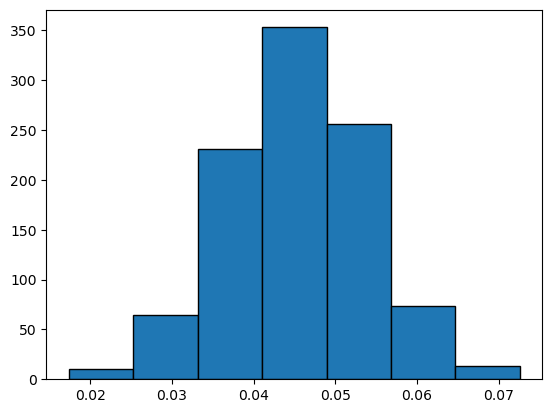

In [4]:
mu = np.average(avg_long) # 0.045523771842320766
std = np.std(avg_long) # 0.00831968659585281

plt.hist(np.random.normal(mu, std, 1000), bins=7, edgecolor='black')
plt.show()

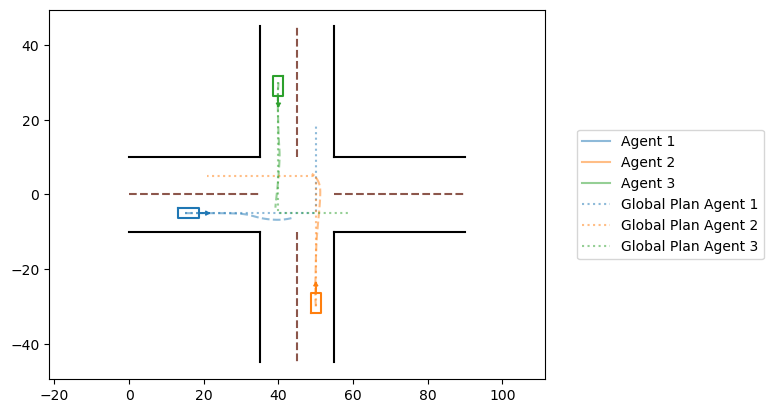

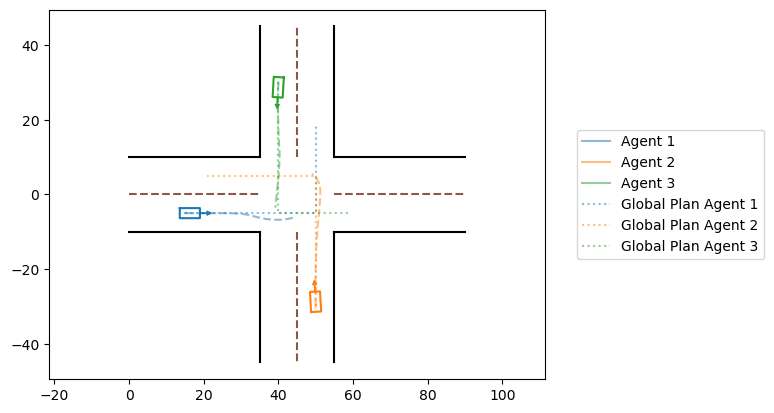

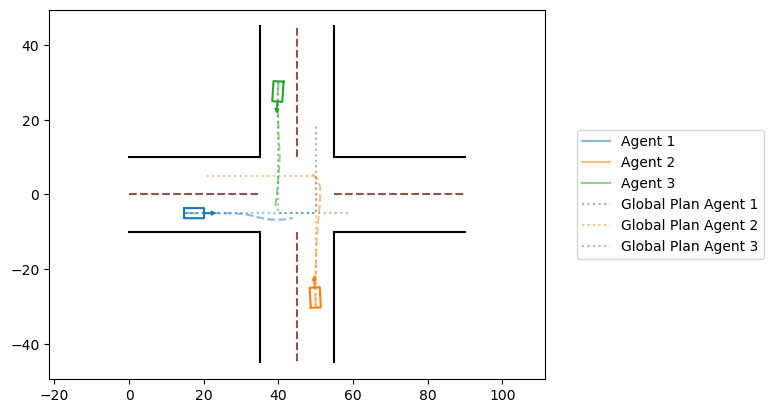

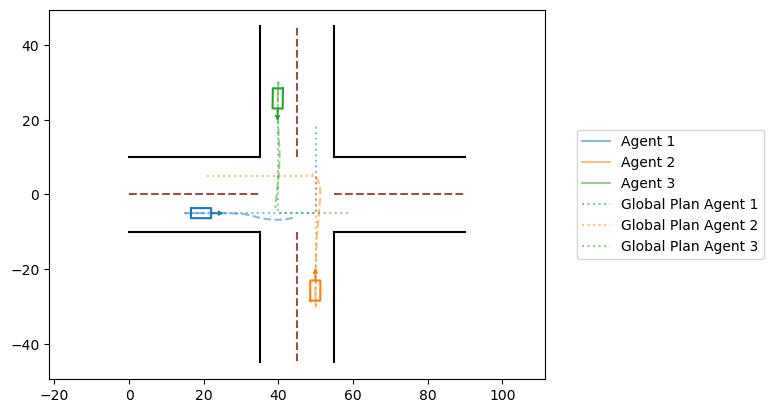

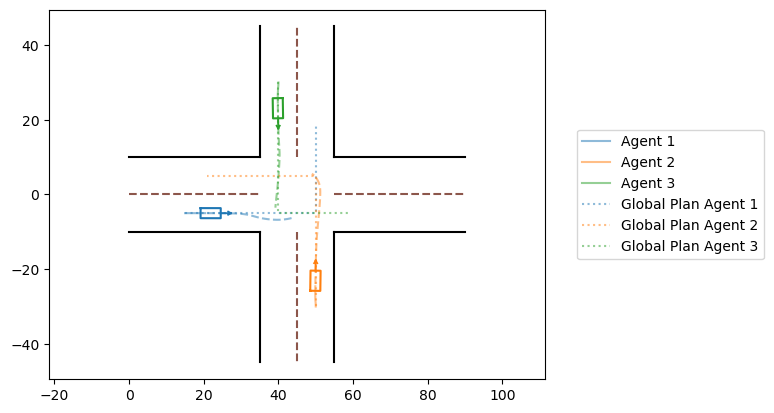

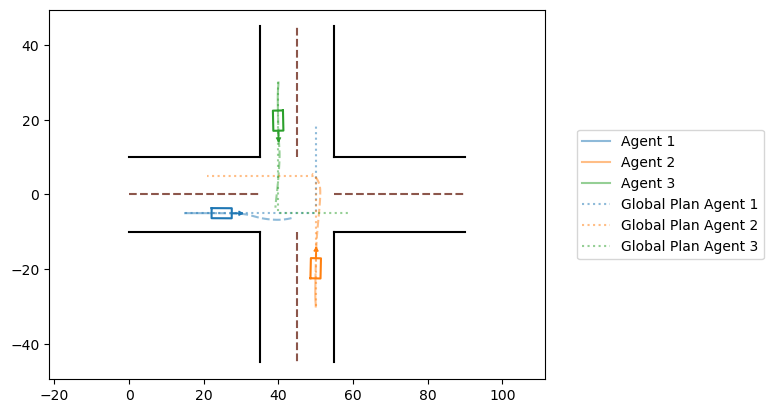

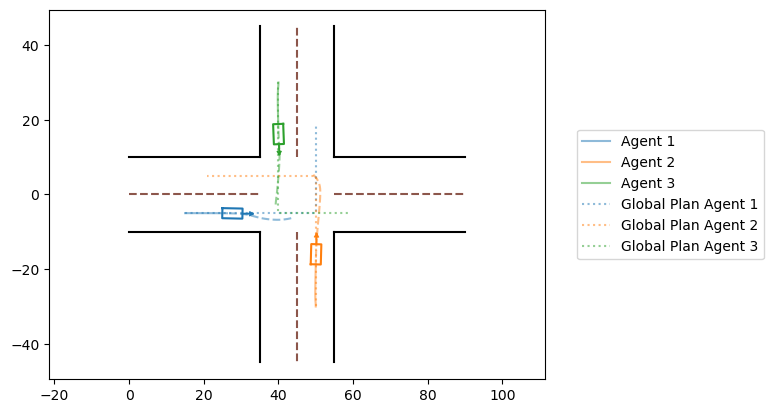

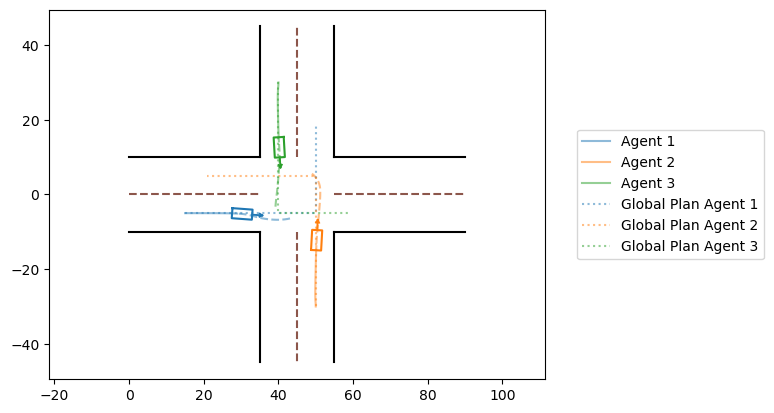

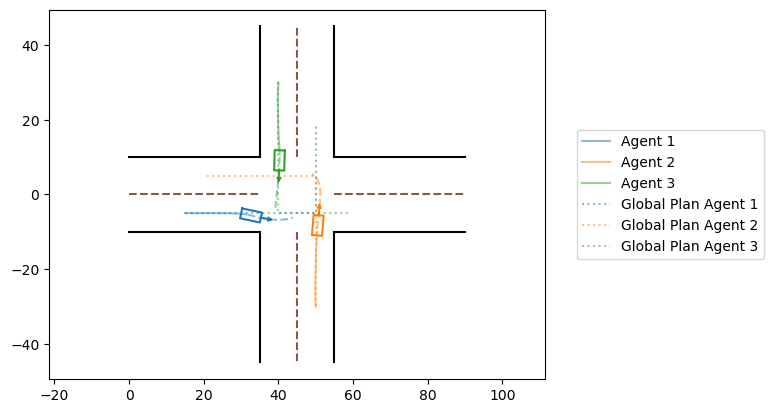

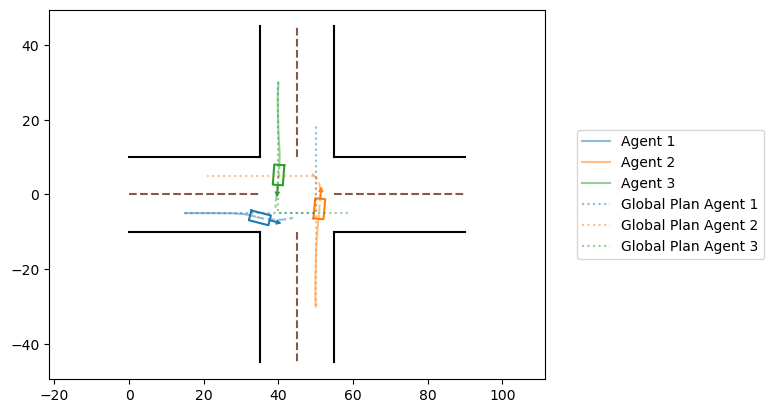

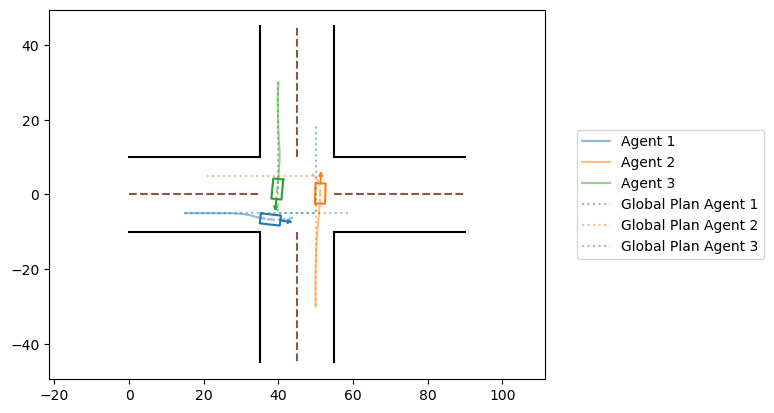

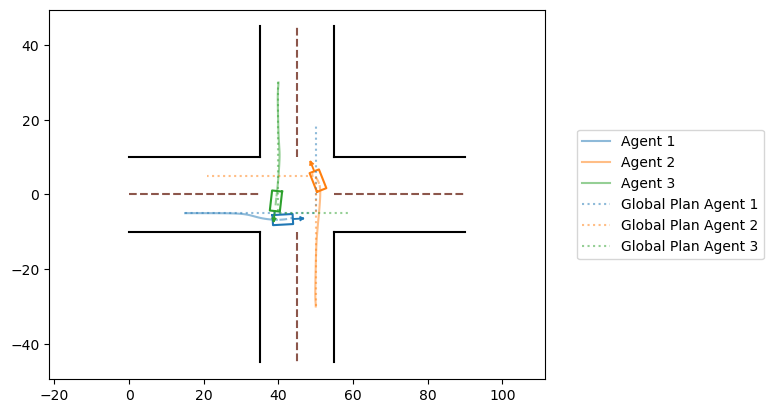

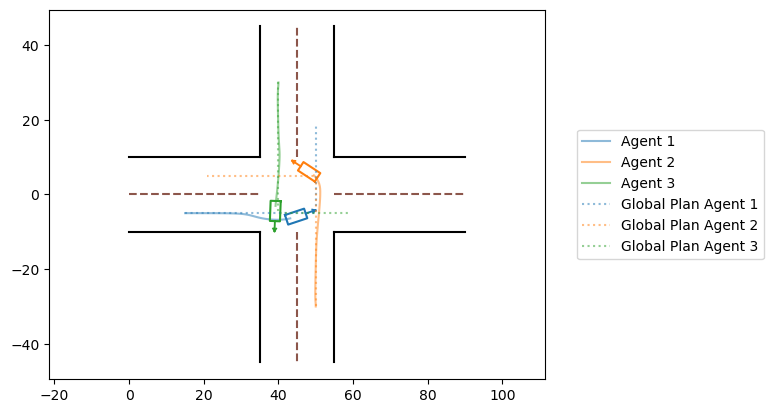

In [3]:
masim.visualize_all(interval=5)

In [5]:
for i in range(25, 35):
    print(masim.agent3_states_short[i])

[39.91159012 20.42228431  6.15569387  4.73663232]
[39.92684332 19.79323657  6.42895889  4.73755787]
[39.94336644 19.13688538  6.7022239   4.73848341]
[39.96121002 18.45323256  6.97548892  4.73940896]
[39.98042462 17.74228002  7.24875393  4.74033451]
[40.00106079 17.00402974 12.52201895  4.74126006]
[40.05072989 15.6649141   6.84938628  4.76093762]
[40.08327365 14.99510784  6.56254173  4.76504801]
[40.11782293 14.33962034  6.56540563  4.77057639]
[40.15601209 13.68404796  6.56826953  4.77610477]


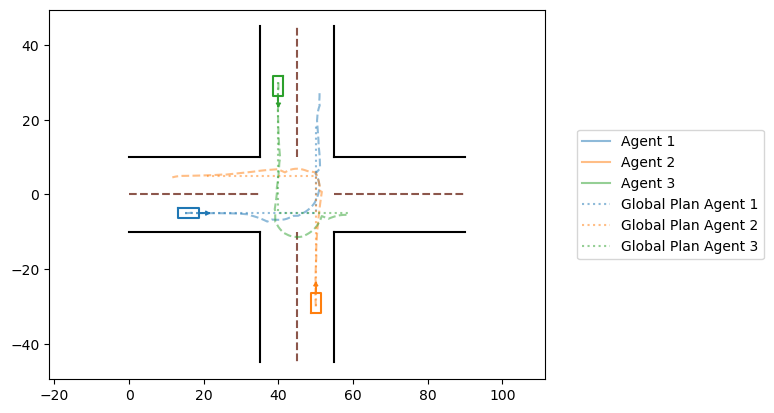

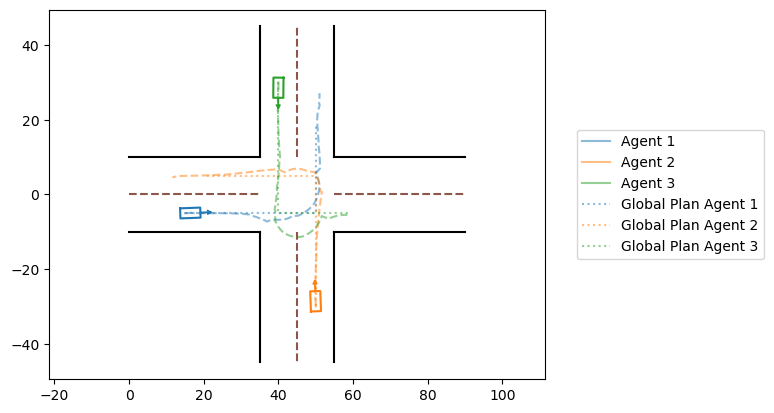

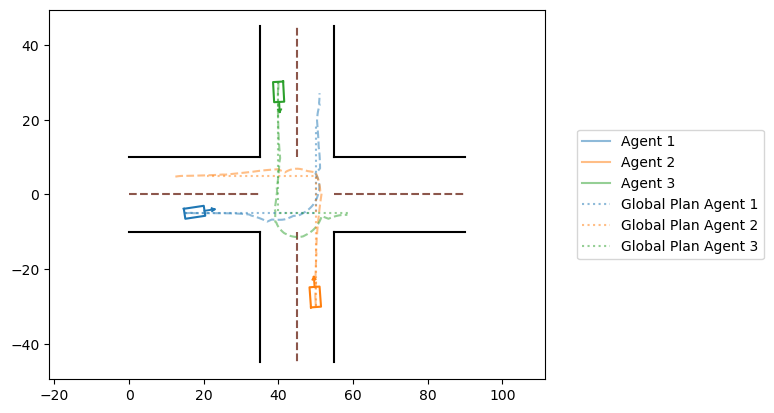

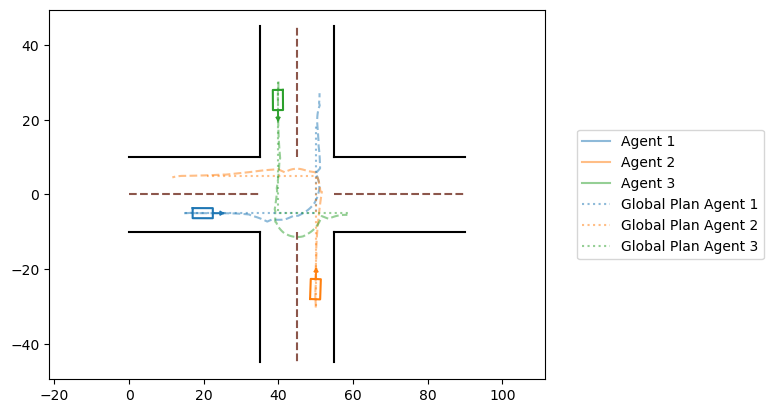

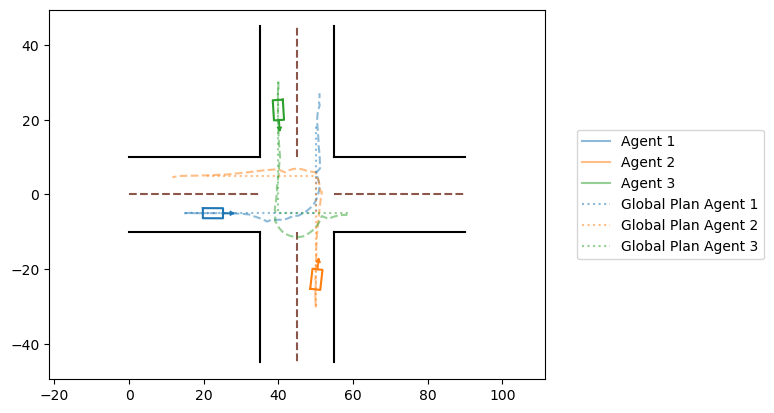

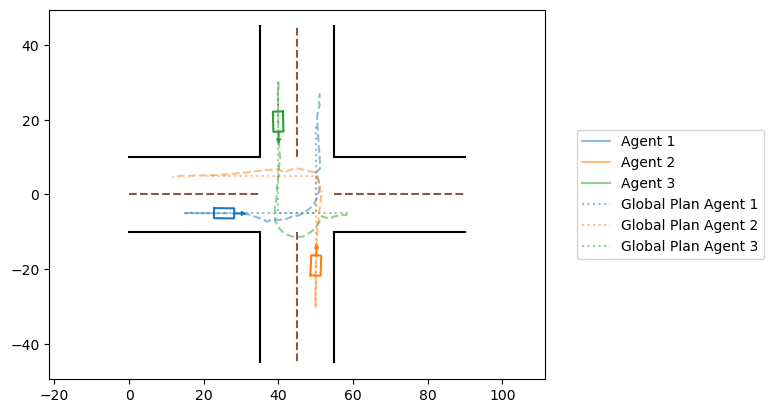

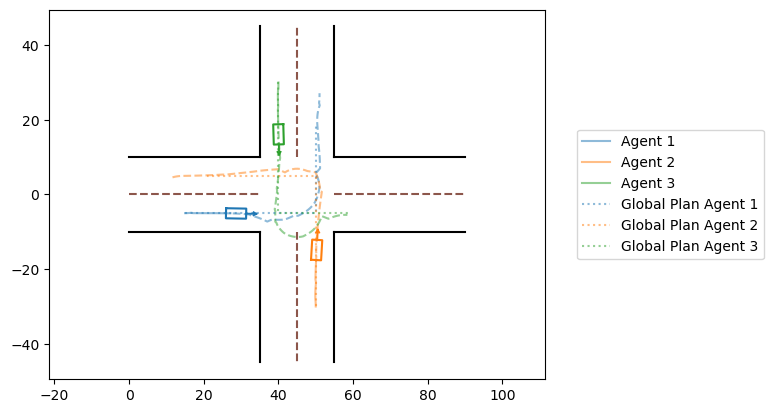

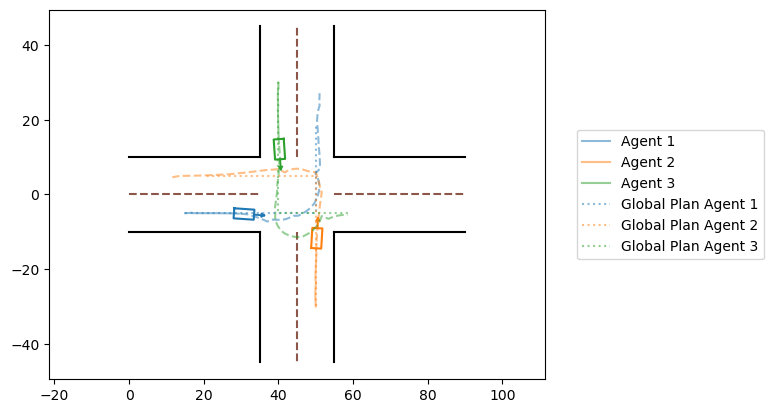

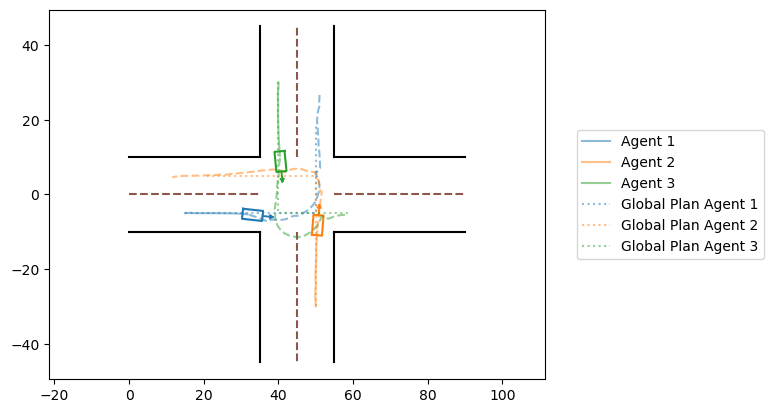

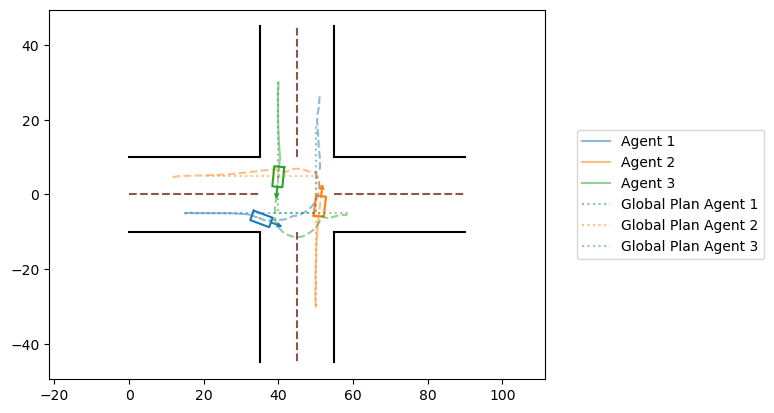

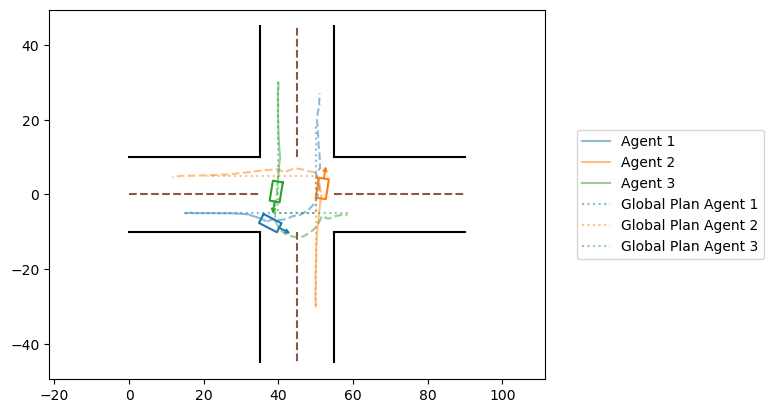

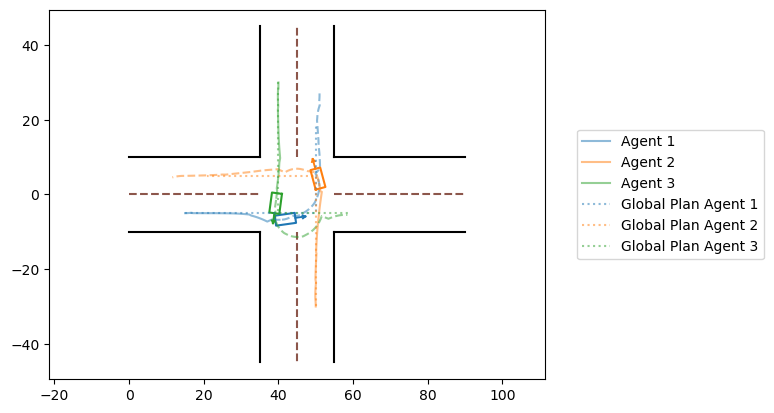

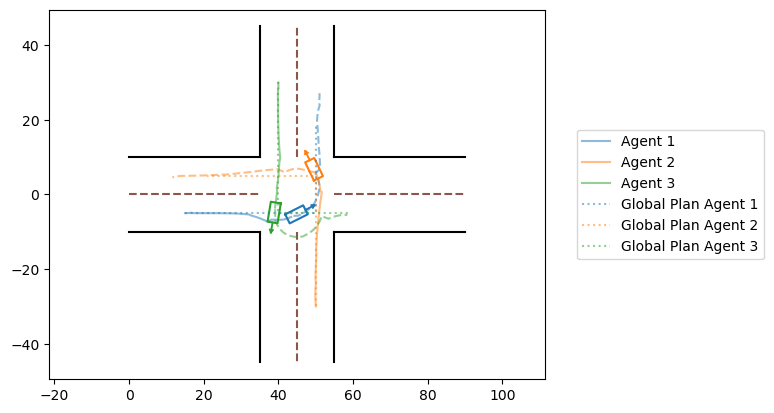

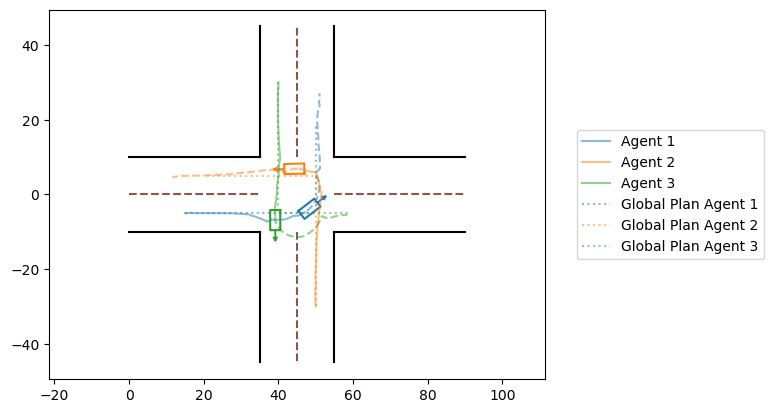

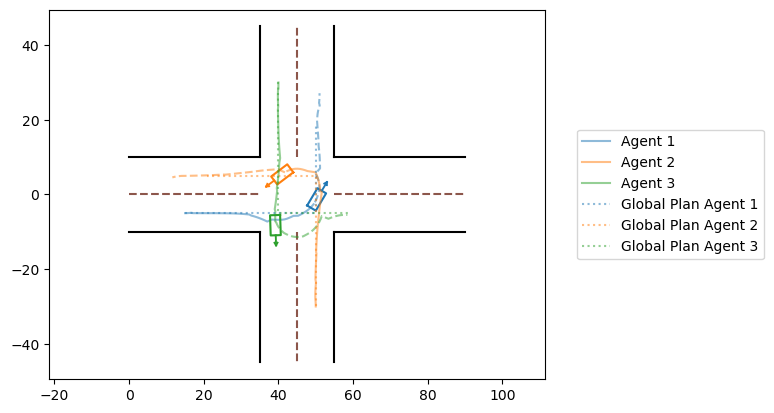

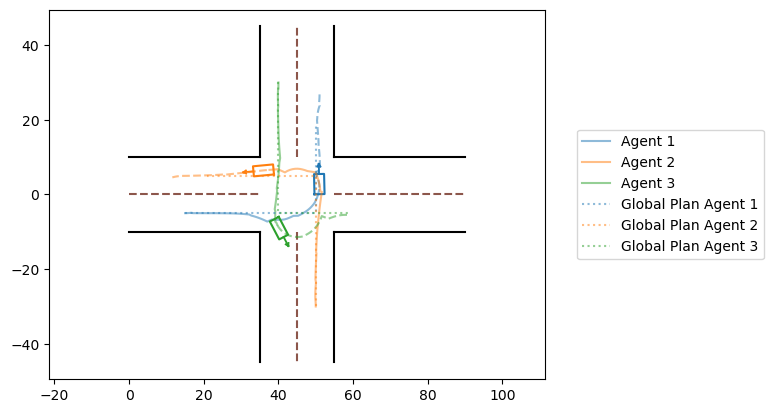

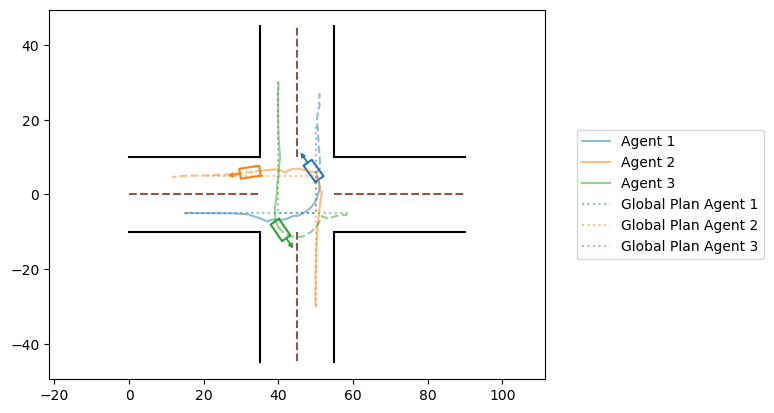

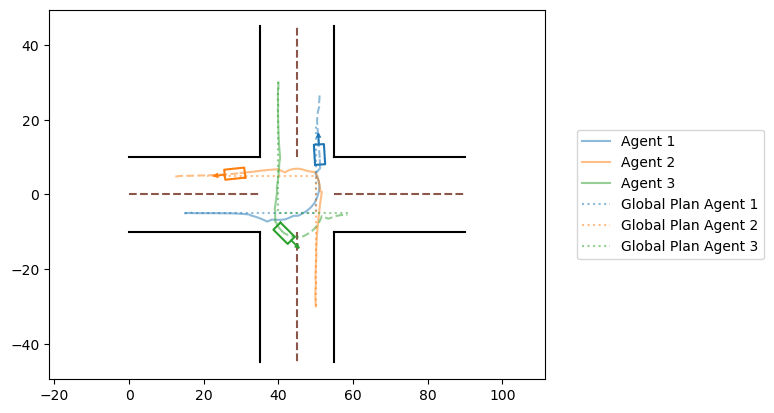

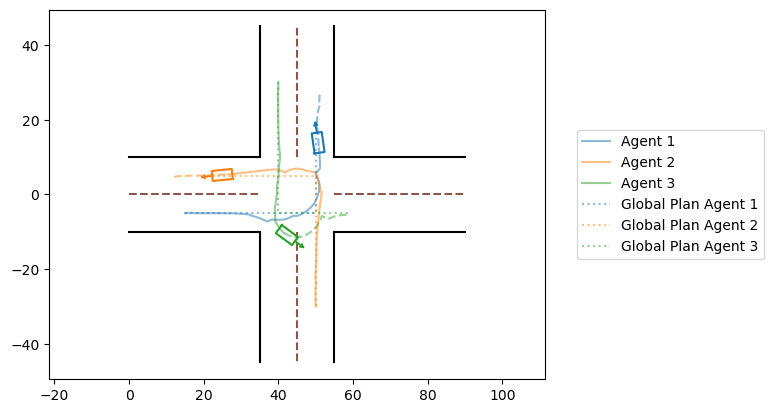

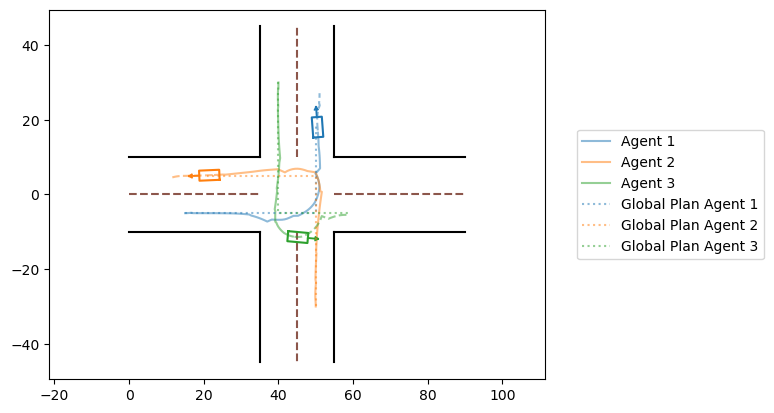

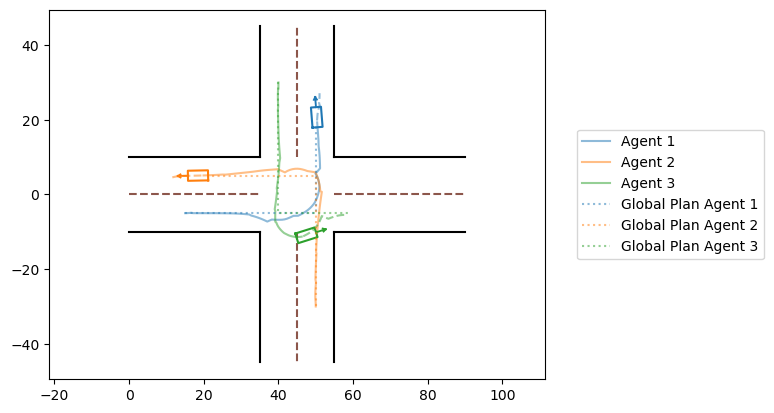

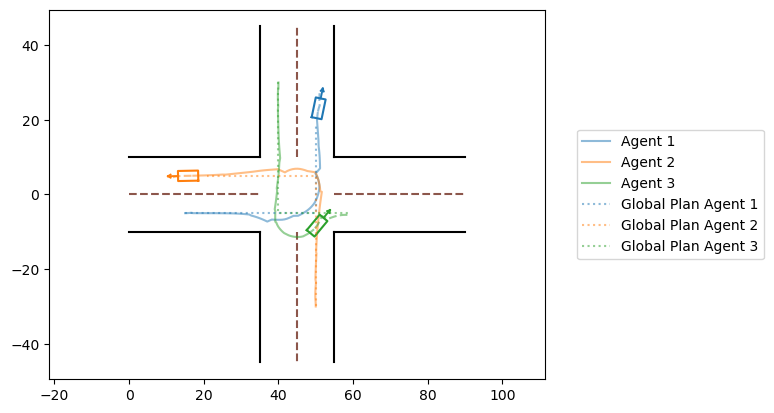

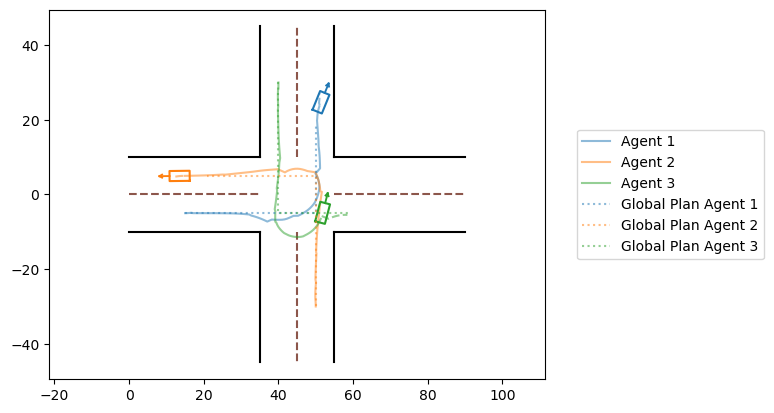

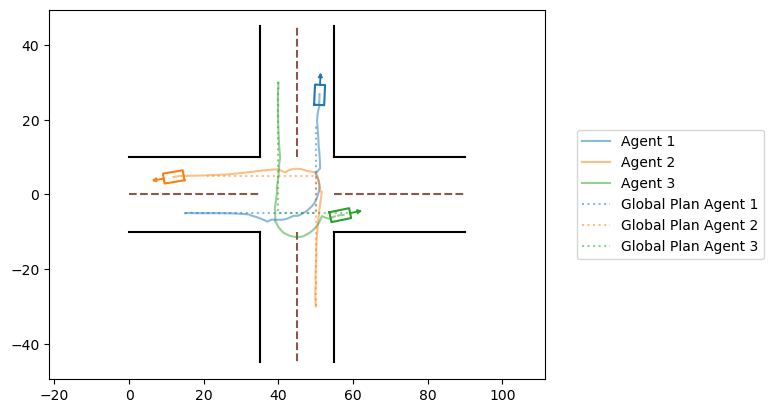

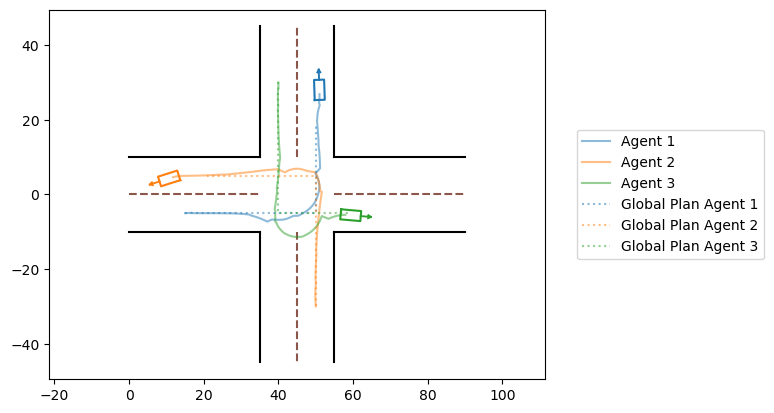

In [3]:
masim.visualize_all_short(interval=5)

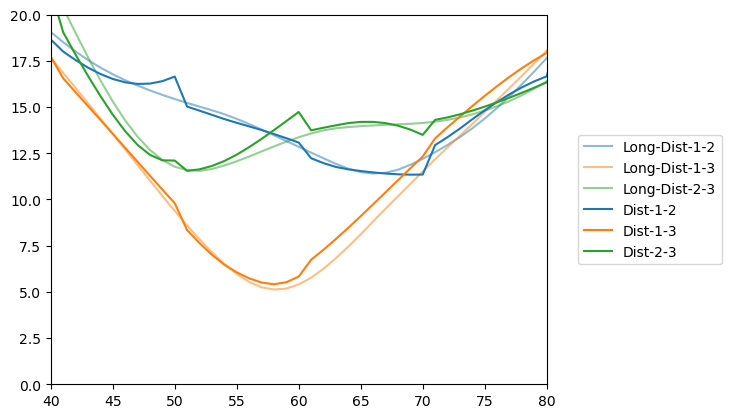

In [6]:
def compute_distance(agent1, agent2):
    return np.linalg.norm(np.array(agent1)[:,:2]-np.array(agent2)[:,:2], 2, axis=1)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# plt.plot(compute_distance(create_global_plan_1(), create_global_plan_3()[5:]), label='Ref-Dist-1-3', linestyle='--', alpha=0.3, color=colors[1])
# plt.plot(compute_distance(create_global_plan_2(), create_global_plan_3()[4:]), label='Ref-Dist-2-3', linestyle='--', alpha=0.3, color=colors[3])
plt.plot(compute_distance(masim.agent1_states_long, masim.agent2_states_long), label='Long-Dist-1-2', color=colors[0], alpha=0.5)
plt.plot(compute_distance(masim.agent1_states_long, masim.agent3_states_long), label='Long-Dist-1-3', color=colors[1], alpha=0.5)
plt.plot(compute_distance(masim.agent2_states_long, masim.agent3_states_long), label='Long-Dist-2-3', color=colors[2], alpha=0.5)

plt.plot(compute_distance(masim.agent1_states_short, masim.agent2_states_short), label='Dist-1-2', color=colors[0])
plt.plot(compute_distance(masim.agent1_states_short, masim.agent3_states_short)+0.5, label='Dist-1-3', color=colors[1])
plt.plot(compute_distance(masim.agent2_states_short, masim.agent3_states_short), label='Dist-2-3', color=colors[2])
plt.xlim(40, 80)
plt.ylim(0, 20)

plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))

In [ ]:
import argparse
from arguments import add_arguments
from ilqr.vehicle_model import Model
import numpy as np


argparser = argparse.ArgumentParser([])
add_arguments(argparser)
argparser.add_argument('--number_of_agents', type=int, default=4, help='Number of agents')
argparser.add_argument('--sim_options', default="cross", type=str, help="Type of simulation, cross")
argparser.add_argument('--epochs', type=int, default=80, help='Total number of epochs for all agents')
argparser.add_argument('--loop_tol', type=int, default=5, help='tolerance of the loop')
argparser.add_argument('--state_gaussian_noise', nargs="*", type=float, default=[0.01]*4, help='State disturbance: x, y, v, yaw')
args = argparser.parse_args([])

qm = Model(args)

x = np.random.rand(4,20)
u = np.random.rand(2,20)

In [ ]:
# A_cpp = qm.get_A_matrix(x[2], x[3], u[0], 20)
# A_py = qm.get_A_matrix_py(x[2], x[3], u[0], 20)
# # print(A_cpp[:,:,0])
# # print(A_py[:,:,0])

# B_cpp = qm.get_B_matrix(x[3], 20)
# B_py = qm.get_B_matrix_py(x[3], 20)
# # print(B_cpp[:,:,0])
# # print(B_py[:,:,0])

In [ ]:
x = np.random.rand(4,1)
u = np.random.rand(2,1)
xnext_cpp = qm.forward_simulate(x, u)
xnext_py = qm.forward_simulate_py(x, u)
print(xnext_cpp)
print(xnext_py)